Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from random import randint

Generate Synthetic Dataset

In [2]:
rng_seed = 42
np.random.seed(rng_seed)

n = 100000

data = pd.DataFrame({
    "Customer_ID": range(1, n+1),
    "Age": np.random.randint(18, 70, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Tenure": np.random.randint(0, 11, n),
    "Balance": np.random.randint(0, 200000, n),
    "CreditScore": np.random.randint(300, 901, n),
    "EstimatedSalary": np.random.randint(10000, 150001, n),
    "NumOfProducts": np.random.randint(1, 5, n),
    "IsActiveMember": np.random.choice([0, 1], n)
})


data["Churn"] = (
    (data["Balance"] < 50000).astype(int) +
    (data["IsActiveMember"] == 0).astype(int) +
    (data["CreditScore"] < 500).astype(int)
)

data["Churn"] = data["Churn"].apply(lambda x: 1 if x >= 2 else 0)

print(data.head())

   Customer_ID  Age  Gender  Tenure  Balance  CreditScore  EstimatedSalary  \
0            1   56  Female       6   117444          424           128126   
1            2   69  Female       5    19619          405            94708   
2            3   46    Male       6   193753          881            49658   
3            4   32    Male       9   182570          823            61391   
4            5   60    Male       2    19321          570            21378   

   NumOfProducts  IsActiveMember  Churn  
0              1               1      0  
1              1               0      1  
2              4               0      0  
3              3               0      0  
4              4               0      1  


Data Cleaning & Preprocessing

In [3]:
# Check missing values
missing_values = data.isnull().sum()
print(missing_values)

# Data types
column_types = data.dtypes
print(column_types)

# Encode Gender
data["Gender"] = data["Gender"].map({"Male": 0, "Female": 1})

Customer_ID        0
Age                0
Gender             0
Tenure             0
Balance            0
CreditScore        0
EstimatedSalary    0
NumOfProducts      0
IsActiveMember     0
Churn              0
dtype: int64
Customer_ID         int64
Age                 int64
Gender             object
Tenure              int64
Balance             int64
CreditScore         int64
EstimatedSalary     int64
NumOfProducts       int64
IsActiveMember      int64
Churn               int64
dtype: object


Descriptive Statistics

In [4]:
print("Mean:\n", data.mean(numeric_only=True))
print("\nMedian:\n", data.median(numeric_only=True))
print("\nStd Dev:\n", data.std(numeric_only=True))

# Mode
print("\nMode:\n", data.mode().iloc[0])

Mean:
 Customer_ID        50000.50000
Age                   43.50027
Gender                 0.49880
Tenure                 4.99056
Balance            99716.21133
CreditScore          599.95792
EstimatedSalary    79974.43629
NumOfProducts          2.50138
IsActiveMember         0.50104
Churn                  0.29178
dtype: float64

Median:
 Customer_ID        50000.5
Age                   43.0
Gender                 0.0
Tenure                 5.0
Balance            99665.5
CreditScore          599.0
EstimatedSalary    80036.0
NumOfProducts          3.0
IsActiveMember         1.0
Churn                  0.0
dtype: float64

Std Dev:
 Customer_ID        28867.657797
Age                   14.970933
Gender                 0.500001
Tenure                 3.163813
Balance            57671.454404
CreditScore          173.286152
EstimatedSalary    40436.829792
NumOfProducts          1.117565
IsActiveMember         0.500001
Churn                  0.454584
dtype: float64

Mode:
 Customer_ID        

Churn Behavior Analysis

In [5]:
churn_rate = data["Churn"].value_counts(normalize=True).sort_index()
print(churn_rate.sort_index())

# Compare churn vs non-churn
print(data.groupby("Churn").mean(numeric_only=True))

Churn
0    0.70822
1    0.29178
Name: proportion, dtype: float64
        Customer_ID        Age    Gender    Tenure        Balance  \
Churn                                                               
0      49948.256262  43.521575  0.499661  4.992869  113035.575767   
1      50127.308075  43.448557  0.496710  4.984954   67386.921173   

       CreditScore  EstimatedSalary  NumOfProducts  IsActiveMember  
Churn                                                               
0       647.338285     79927.884513       2.497896        0.647186  
1       484.954418     80087.428611       2.509836        0.146309  


Group-Based Analysis

In [6]:
# Age group
data["AgeGroup"] = pd.cut(data["Age"], bins=[18,30,45,60,70],
                         labels=["18-30","30-45","45-60","60-70"])

print(data.groupby("AgeGroup")["Churn"].mean())

# Gender vs churn
print(data.groupby("Gender")["Churn"].mean())

# Active vs churn
print(data.groupby("IsActiveMember")["Churn"].mean())

# Products vs churn
print(data.groupby("NumOfProducts")["Churn"].mean())

AgeGroup
18-30    0.291752
30-45    0.291954
45-60    0.293142
60-70    0.287343
Name: Churn, dtype: float64
Gender
0    0.292997
1    0.290557
Name: Churn, dtype: float64
IsActiveMember
0    0.499218
1    0.085203
Name: Churn, dtype: float64
NumOfProducts
1    0.291251
2    0.287185
3    0.292664
4    0.296007
Name: Churn, dtype: float64


/tmp/ipykernel_9692/2524075617.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data.groupby("AgeGroup")["Churn"].mean())


Relationship Analysis

In [7]:
print(data[["Balance", "Churn"]].corr())
print(data[["CreditScore", "Churn"]].corr())
print(data[["Tenure", "Churn"]].corr())

          Balance     Churn
Balance  1.000000 -0.359817
Churn   -0.359817  1.000000
             CreditScore     Churn
CreditScore     1.000000 -0.425984
Churn          -0.425984  1.000000
          Tenure     Churn
Tenure  1.000000 -0.001137
Churn  -0.001137  1.000000


Data Visualization

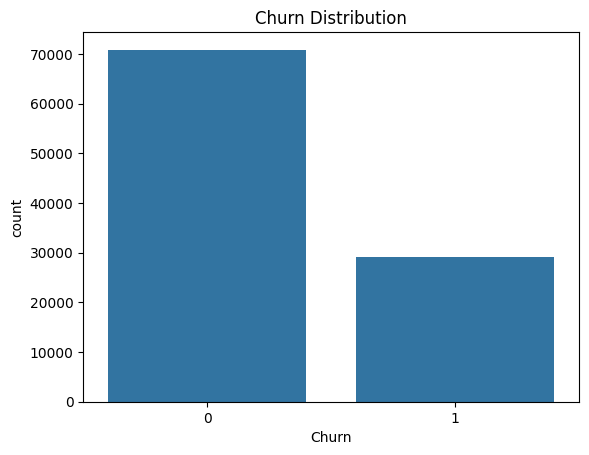

In [8]:
sns.countplot(x="Churn", data=data)
plt.title("Churn Distribution")
plt.show()

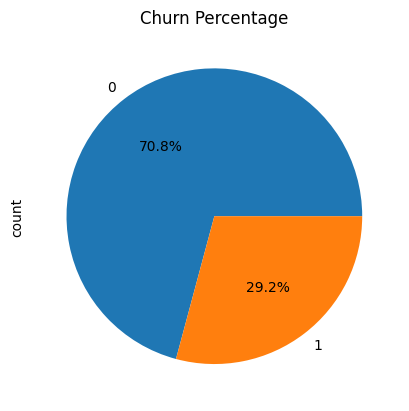

In [9]:
data["Churn"].value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Churn Percentage")
plt.show()

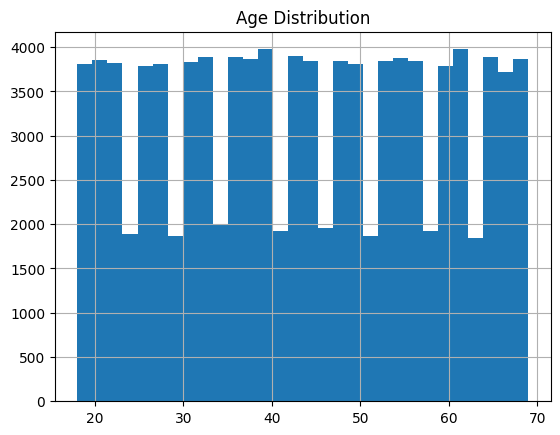

In [10]:
data["Age"].hist(bins=30)
plt.title("Age Distribution")
plt.show()

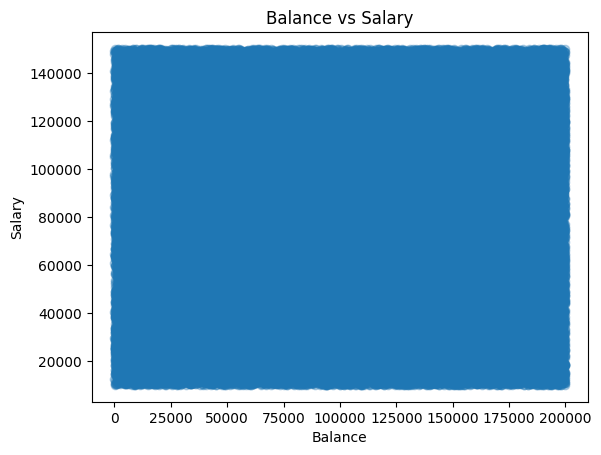

In [11]:
plt.scatter(data["Balance"], data["EstimatedSalary"], alpha=0.3)
plt.xlabel("Balance")
plt.ylabel("Salary")
plt.title("Balance vs Salary")
plt.show()

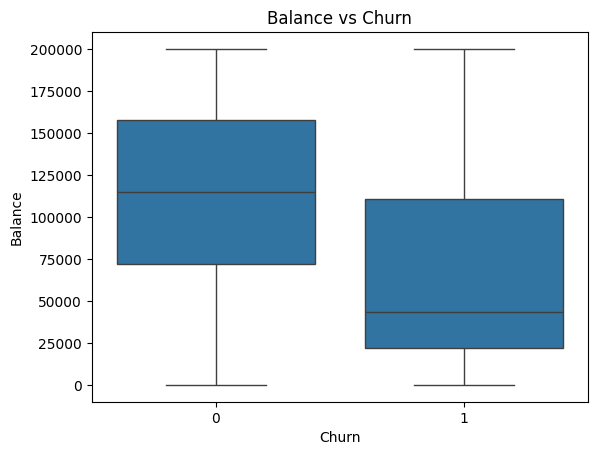

In [12]:
sns.boxplot(x="Churn", y="Balance", data=data)
plt.title("Balance vs Churn")
plt.show()

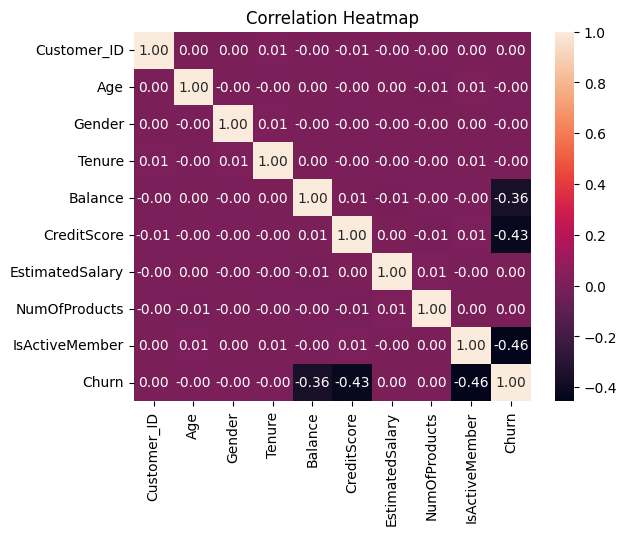

In [13]:
corr = data.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [14]:
print("Insights:")
print("- Customers with low balance are more likely to churn.")
print("- Inactive members have higher churn rate.")
print("- Low credit score increases churn risk.")
print("- Customers with fewer products tend to leave more.")

Insights:
- Customers with low balance are more likely to churn.
- Inactive members have higher churn rate.
- Low credit score increases churn risk.
- Customers with fewer products tend to leave more.
